In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
import sklearn.metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [29]:
df=pd.read_csv("social.csv")
x=df.iloc[:,2:4]
y=df.iloc[:,4] # using 1:3 as indicies will give an array of dim (10,1)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [33]:
x_sca=StandardScaler()
x_train=x_sca.fit_transform(x_train)
x_test=x_sca.transform(x_test)


#Key rule: Always fit only on training data, then transform both train and test — to avoid data leakage.

In [34]:
clf=KNeighborsClassifier(n_neighbors=5,metric="minkowski",p=2)
clf=clf.fit(x_train,y_train)

In [35]:
y_pread=clf.predict(x_test)
y_pread

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0], dtype=int64)

In [50]:
cm=confusion_matrix(y_test,y_pread)
cm

array([[56,  5],
       [ 2, 37]], dtype=int64)

In [47]:
acc=accuracy_score(y_test,y_pread)
print(f"the accuracy is :{acc}")
cr=classification_report(y_test,y_pread)
print(cr)

the accuracy is :0.93
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        61
           1       0.88      0.95      0.91        39

    accuracy                           0.93       100
   macro avg       0.92      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



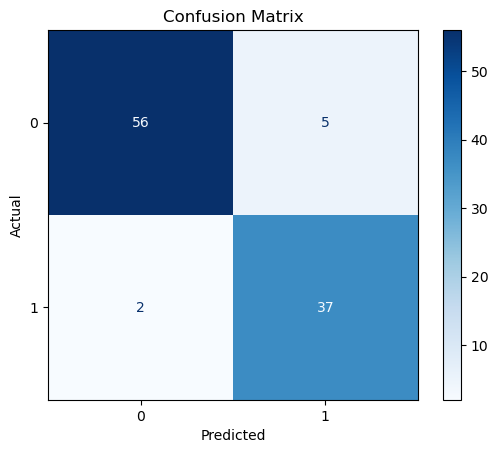

In [61]:
# ploting confusion matrix here
# plt.imshow(cm)

# from sklearn.metrics import ConfusionMatrixDisplay
# disp=ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot(cm=plt.cm.Blues)
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("confusion matrix")

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6484\2097381238.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


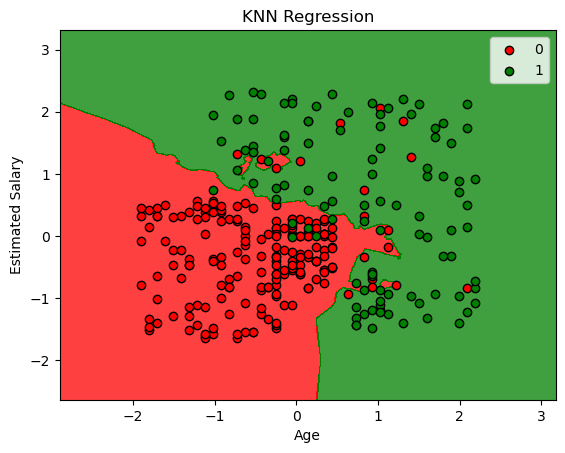

In [48]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_set, y_set = x_train, y_train

# generates every pixel in the table. meshgrid creates one entry point x1 to x2
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)

# classifies every pixel as 0 or 1
plt.contourf(x1, x2, clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
             alpha=0.75, cmap=ListedColormap(("red", "green")))

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c=ListedColormap(("red", "green"))(i), label=j, edgecolor="black")

plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
plt.legend()
plt.title("KNN Regression")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()

# Another way to do it 

In [5]:
x=np.array([[4,3],[6,7],[7,8],[5,5],[8,8]])
y=np.array(['F','P','P','F','P'])


In [25]:
target=np.array([[6,8]])

In [10]:
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x,y)

KNeighborsClassifier(n_neighbors=3)

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [27]:
y_pread=model.predict(target)
print(y_pread[0])

P


## Feature Scaling

Because in Machine Learning models, features are mapped into n-dimensional space. So let's say there are two variables (x, y) which will be mapped in 2D co-ordinate system. If one variable, say y, is very huge and other, x, is very small, then the euclidean distance will be dominated by the bigger one and smaller one will be ignored. In this case we are losing valuable information, hence feature scaling is used to solve this problem. 


Additional reasons for transformation:

1. To more closely approximate a theoretical distribution that has nice statistical properties. 
2. To spread out data more evenly.
3. To make data distribution more symmetric
4. to make relationships between variables more linear. 
5. TO make data more constant in variance (homoscedasticity). 

#### There are 3 most used ways to scale features. 
1. __Min Max Scaling__: 
Will scale the input to have minimum of 0 and maximum of 1. That is, it scales the data in the range of [0, 1] This is useful when the parameters have to be on same positive scale. But in this case, the outliers are lost. 
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

2. __Standardization__:
Will scale the input to have mean of 0 and variance of 1. 
$$X_{stand} = \frac{X - \mu}{\sigma}$$